In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
#Load the dataset
df = pd.read_csv('backend\\datasets\\creditcard.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123600 entries, 0 to 123599
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Transaction_ID                114000 non-null  str    
 1   User_ID                       114000 non-null  float64
 2   Transaction_Amount            114236 non-null  float64
 3   Transaction_Type              114000 non-null  str    
 4   Timestamp                     114000 non-null  str    
 5   Account_Balance               114000 non-null  float64
 6   Device_Type                   114000 non-null  str    
 7   Location                      114000 non-null  str    
 8   Merchant_Category             114000 non-null  str    
 9   IP_Address_Flag               114000 non-null  float64
 10  Previous_Fraudulent_Activity  114000 non-null  float64
 11  Daily_Transaction_Count       114000 non-null  float64
 12  Avg_Transaction_Amount_7d     114000 non-null  float64


In [88]:
print("Shape of the Dataset:", df.shape)
#Missing Values present in the dataset
null_values = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100

null_df = pd.DataFrame({
    "Null Values": null_values,
    "Null Percentage": null_percentage
})

null_df[null_df["Null Values"] > 0]

Shape of the Dataset: (123600, 23)


,Null Values,Null Percentage
Transaction_ID,9600,7.766990
User_ID,9600,7.766990
Transaction_Amount,9364,7.576052
Transaction_Type,9600,7.766990
Timestamp,9600,7.766990
Account_Balance,9600,7.766990
Device_Type,9600,7.766990
Location,9600,7.766990
Merchant_Category,9600,7.766990
IP_Address_Flag,9600,7.766990


In [89]:
df.describe()

,User_ID,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,114000.000000,114236.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,123600.000000
mean,499944.197000,288.899196,50311.990355,0.050456,0.097474,7.484605,255.256683,2.007386,119.902132,2497.847235,0.502167,0.299412,0.322144
std,288298.264168,1814.413378,28722.016917,0.218885,0.296603,4.038318,141.515749,1.415050,68.958848,1443.373115,0.288075,0.458003,0.467300
min,1009.000000,0.000000,500.480000,0.000000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,250458.000000,29.100000,25460.770000,0.000000,0.000000,4.000000,132.010000,1.000000,60.000000,1252.090000,0.254300,0.000000,0.000000
50%,499061.500000,70.700000,50352.375000,0.000000,0.000000,7.000000,256.075000,2.000000,120.000000,2489.490000,0.503000,0.000000,0.000000
75%,749603.750000,142.122500,75110.040000,0.000000,0.000000,11.000000,378.282500,3.000000,179.000000,3744.720000,0.751100,1.000000,1.000000
max,999981.000000,17612.100000,99998.310000,1.000000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


In [90]:
#Duplicate Value Analysis
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)
print("Duplicate Percentage:", (duplicate_count / len(df)) * 100)
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Total Duplicate Rows: 9596
Duplicate Percentage: 7.763754045307443
Shape after removing duplicates: (114004, 23)


Fraud_Label
0    77192
1    36812
Name: count, dtype: int64

Fraud Label Percentage:
Fraud_Label
0    67.709905
1    32.290095
Name: proportion, dtype: float64


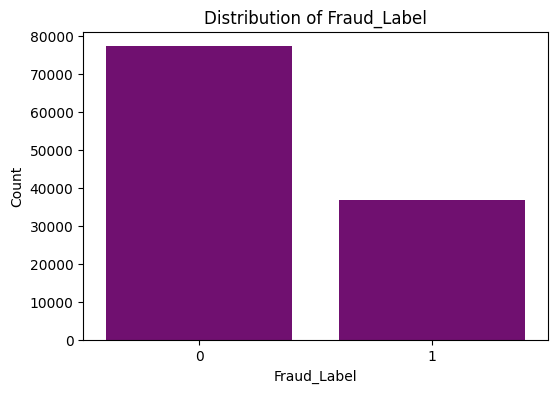

In [91]:
#Fraud Label Distribution
print(df['Fraud_Label'].value_counts())
print("\nFraud Label Percentage:")
print(df["Fraud_Label"].value_counts(normalize=True) * 100)
plt.figure(figsize=(6, 4))
sns.countplot(x='Fraud_Label', data=df, color = "purple")
plt.title('Distribution of Fraud_Label')
plt.xlabel('Fraud_Label')
plt.ylabel('Count')
plt.show()

In [92]:
#Transaction Amount Analysis
print("Transaction Amount Summary:")
df["Transaction_Amount"].describe()


Transaction Amount Summary:


count    114002.000000
mean        253.341670
std        1637.563253
min           0.000000
25%          29.012500
50%          70.490000
75%         141.447500
max       17612.100000
Name: Transaction_Amount, dtype: float64

In [93]:
#Spending Behaviour Analysis
spending_analysis = df.groupby("Fraud_Label")["Transaction_Amount"].agg(
    ["mean", "median", "min", "max", "std"]
)

print("Spending Behaviour Analysis:")
print(spending_analysis)



Spending Behaviour Analysis:
                   mean  median   min      max          std
Fraud_Label                                                
0            251.375125   70.12  0.01  17612.1  1627.451136
1            257.465427   71.22  0.00  17612.1  1658.582410


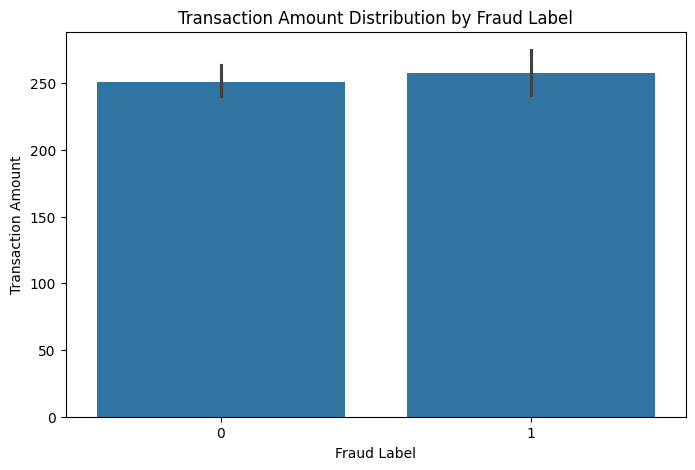

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Fraud_Label", y="Transaction_Amount", data=df)
plt.title("Transaction Amount Distribution by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount")
plt.show()


In [76]:
geo_columns = ["Location", "Foreign_Transaction"]

for col in geo_columns:
    if col in df.columns:
        print(f"\n{col} Fraud Analysis:")
        print(pd.crosstab(df[col], df["Fraud_Label"]))


Location Fraud Analysis:
Fraud_Label      0     1
Location                
London       15406  7269
Mumbai       15612  7255
New York     15204  7428
Sydney       15310  7288
Tokyo        15658  7570


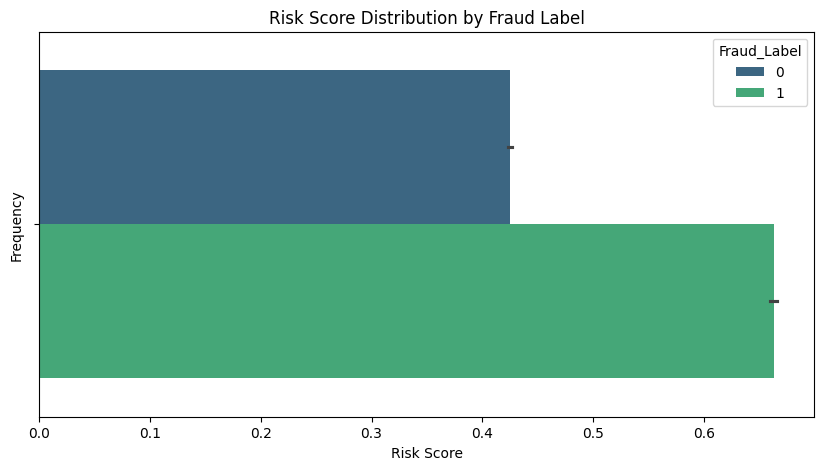

In [84]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Risk_Score", hue="Fraud_Label", palette = "viridis")
plt.title("Risk Score Distribution by Fraud Label")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

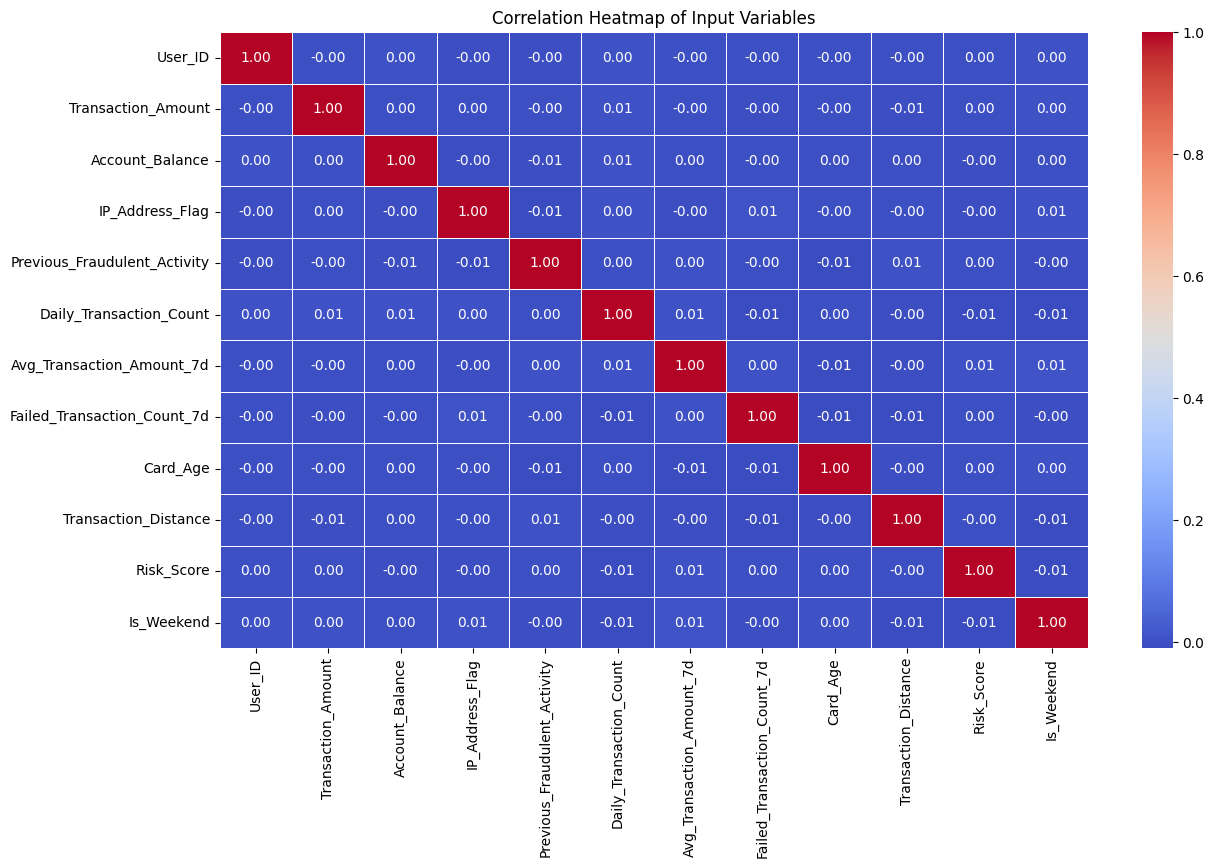

In [95]:
# Correlation Heatmap (Only Input Variables)

# Remove target/output columns
target_columns = ["Fraud_Label"]

# Select only numeric input features
input_features = df.drop(columns=target_columns, errors="ignore")

numeric_inputs = input_features.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr_matrix = numeric_inputs.corr()

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Input Variables")
plt.show()